In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import torch
import pandas as pd
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde
import networkx as nx # Error対策のためここでもインポート

In [2]:
#1~3
# --- 1. SAMと可視化のための関数 ---

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def process_with_sam(image_path, model_checkpoint):
    print("--- SAM解析開始 ---")
    image = cv2.imread(image_path)
    if image is None:
        print(f"エラー: 画像が見つかりません: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"使用デバイス: {device}")
    
    # ★軽量化のため 'vit_b' を推奨しますが、'vit_h' のままであれば以下を使用
    model_type = "vit_b"  
    
    if not os.path.exists(model_checkpoint):
        print(f"エラー: モデルファイル {model_checkpoint} が見つかりません。")
        return None

    print("モデルをロード中...")
    sam = sam_model_registry[model_type](checkpoint=model_checkpoint)
    sam.to(device=device)

    mask_generator = SamAutomaticMaskGenerator(
        model=sam,
        points_per_side=32,
        pred_iou_thresh=0.86,
        stability_score_thresh=0.92,
        crop_n_layers=0,
        crop_n_points_downscale_factor=1,
        min_mask_region_area=100,
    )

    print("セグメンテーション実行中...")
    masks = mask_generator.generate(image)
    print(f"検出された石（領域）の数: {len(masks)}")
    return masks

def sort_masks_bottom_up(masks):
    # bbox[1] (y座標) が大きい順 ＝ 画像の下にある順
    return sorted(masks, key=lambda x: x['bbox'][1], reverse=True)

def visualize_labeled_masks(image, masks, title="Labeled Stones"):
    vis_img = image.copy()
    overlay = vis_img.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    for i, mask in enumerate(masks):
        idx = i + 1
        y_indices, x_indices = np.where(mask['segmentation'])
        if len(y_indices) == 0: continue
        center_y = int(np.mean(y_indices))
        center_x = int(np.mean(x_indices))
        
        color = np.random.randint(0, 255, (3,)).tolist()
        overlay[mask['segmentation']] = color
        
        text = str(idx)
        cv2.putText(vis_img, text, (center_x-10, center_y+10), font, 0.6, (255, 255, 255), 2)

    cv2.addWeighted(overlay, 0.4, vis_img, 0.6, 0, vis_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- 2. メイン処理関数（ここを修正：データをreturnするように変更） ---

def main():
    image_path = "images/pyramid2_test.jpeg"
    checkpoint_path = "sam_vit_b_01ec64.pth" # 適切なパスに変更してください

    # 2-1. SAM実行
    masks = process_with_sam(image_path, checkpoint_path)
    if masks is None:
        return None, None

    # 画像再読み込み（可視化用）
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # 2-2. 対話的修正ループ
    current_masks = sort_masks_bottom_up(masks)
    
    while True:
        visualize_labeled_masks(image_rgb, current_masks, title=f"Check: {len(current_masks)} stones")
        print("【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。")
        user_input = input("削除番号 >> ")
        
        if not user_input.strip():
            break
        
        try:
            remove_ids = set(map(int, user_input.split()))
            new_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
            current_masks = new_masks
            if len(current_masks) == 0: break
        except ValueError:
            print("数値を入力してください。")

    # 2-3. データフレームの作成（これが抜けていたため追加）
    print("データフレームを作成中...")
    data_list = []
    for i, m in enumerate(current_masks):
        data_list.append({
            'Stone_ID': i + 1,
            'Area': m['area'],
            'bbox': m['bbox'] # 後の処理で使うため保存
        })
    df = pd.DataFrame(data_list)

    print("メイン処理完了。データを返却します。")
    # ★重要: ここで変数を外に返す
    return current_masks, df


# --- 3. 分析ロジック（構造石基準の段推定） ---

def add_structural_tiering(masks, df_stones, area_threshold_ratio=1.0):
    """
    大きな石を基準に段(Tier)の範囲を決め、小石を適切な段に割り振る
    """
    print("構造石基準のグルーピングを実行中...")
    
    # 1. 各石の詳細な幾何情報を抽出（重心、上端、下端）
    y_mins, y_maxs, centroids_x, centroids_y = [], [], [], []
    for m in masks:
        y_indices, x_indices = np.where(m['segmentation'])
        if len(y_indices) > 0:
            y_mins.append(np.min(y_indices))
            y_maxs.append(np.max(y_indices))
            centroids_x.append(np.mean(x_indices))
            centroids_y.append(np.mean(y_indices))
        else:
            x, y, w, h = m['bbox']
            y_mins.append(y)
            y_maxs.append(y + h)
            centroids_x.append(x + w/2)
            centroids_y.append(y + h/2)
            
    df_stones['y_min'] = y_mins
    df_stones['y_max'] = y_maxs
    df_stones['Centroid_X'] = centroids_x
    df_stones['Centroid_Y'] = centroids_y

    # 2. 構造石(Structural Stones)の特定：平均面積以上の石を基準とする
    avg_area = df_stones['Area'].mean()
    structural_df = df_stones[df_stones['Area'] >= avg_area * area_threshold_ratio].copy()
    
    # 3. 構造石だけで段の「垂直範囲」を決定する
    structural_df = structural_df.sort_values(by='y_max', ascending=False)
    tier_ranges = {}
    current_tier = 1
    
    if len(structural_df) > 0:
        base_y_max = structural_df.iloc[0]['y_max']
        temp_y_mins = []
        temp_y_maxs = []
        
        for _, row in structural_df.iterrows():
            # 現在の段の底辺から、石の高さの半分以上離れたら「次の段」とみなす
            if abs(row['y_max'] - base_y_max) > (row['y_max'] - row['y_min']) * 0.6:
                # 前の段の範囲を確定
                tier_ranges[current_tier] = {'ymin': min(temp_y_mins), 'ymax': max(temp_y_maxs)}
                current_tier += 1
                base_y_max = row['y_max']
                temp_y_mins = [row['y_min']]
                temp_y_maxs = [row['y_max']]
            else:
                temp_y_mins.append(row['y_min'])
                temp_y_maxs.append(row['y_max'])
        
        # 最後の段を追加
        tier_ranges[current_tier] = {'ymin': min(temp_y_mins), 'ymax': max(temp_y_maxs)}

    # 4. 全ての石を、垂直方向の重なり(Overlap)が最大の段に所属させる
    final_tiers = []
    for _, row in df_stones.iterrows():
        best_tier = 1
        max_overlap = -1
        for t_id, r in tier_ranges.items():
            # 区間の重なりの長さを計算
            overlap = min(row['y_max'], r['ymax']) - max(row['y_min'], r['ymin'])
            if overlap > max_overlap:
                max_overlap = overlap
                best_tier = t_id
        final_tiers.append(best_tier)
    
    df_stones['Tier'] = final_tiers
    return df_stones


--- SAM解析開始 ---
使用デバイス: cpu
モデルをロード中...
セグメンテーション実行中...
検出された石（領域）の数: 81


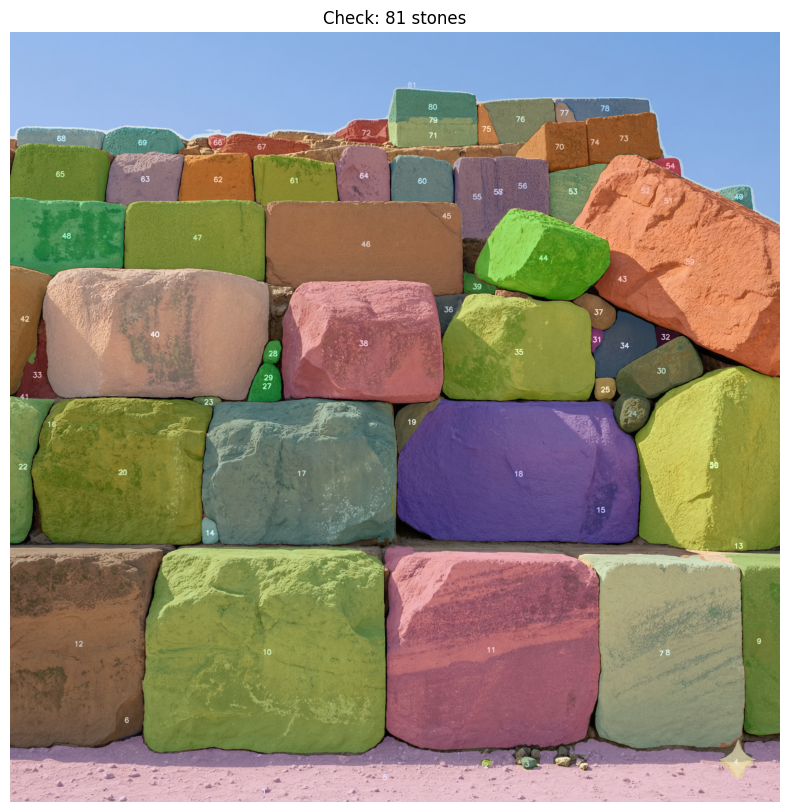

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。


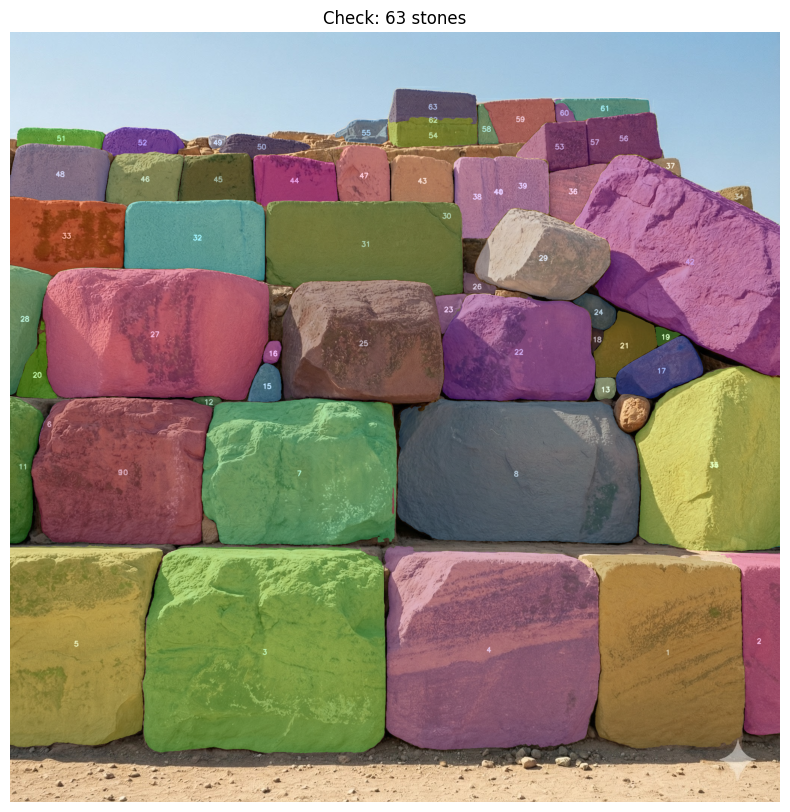

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。


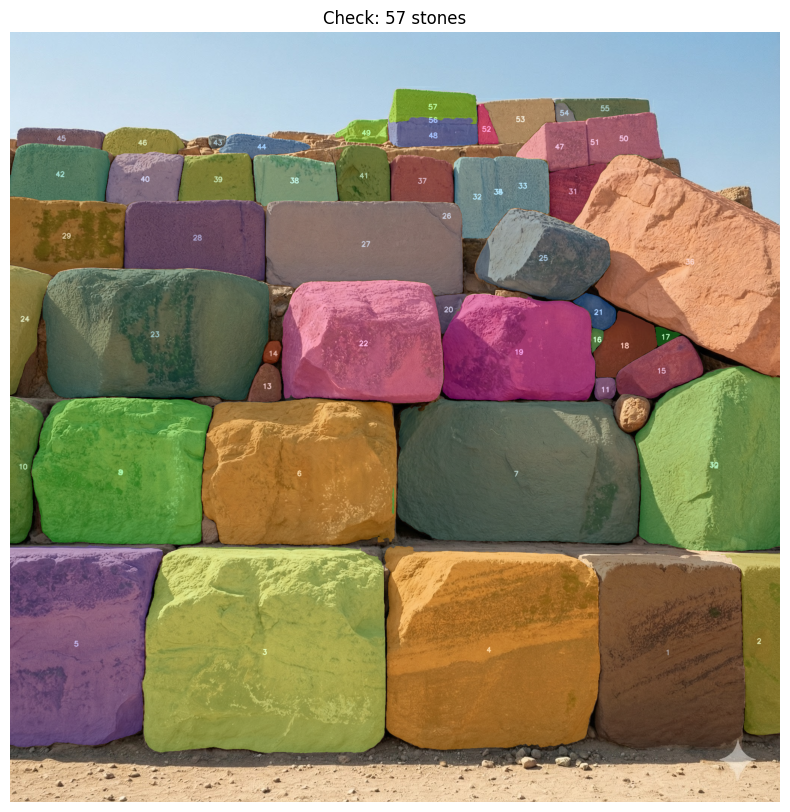

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。


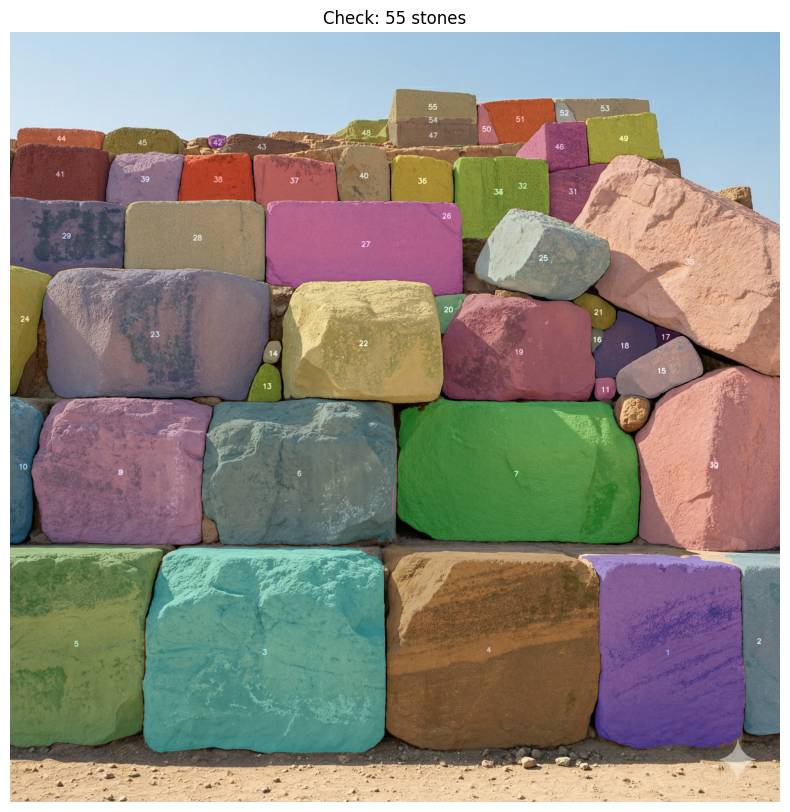

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。
データフレームを作成中...
メイン処理完了。データを返却します。
構造石基準のグルーピングを開始します...
構造石基準のグルーピングを実行中...


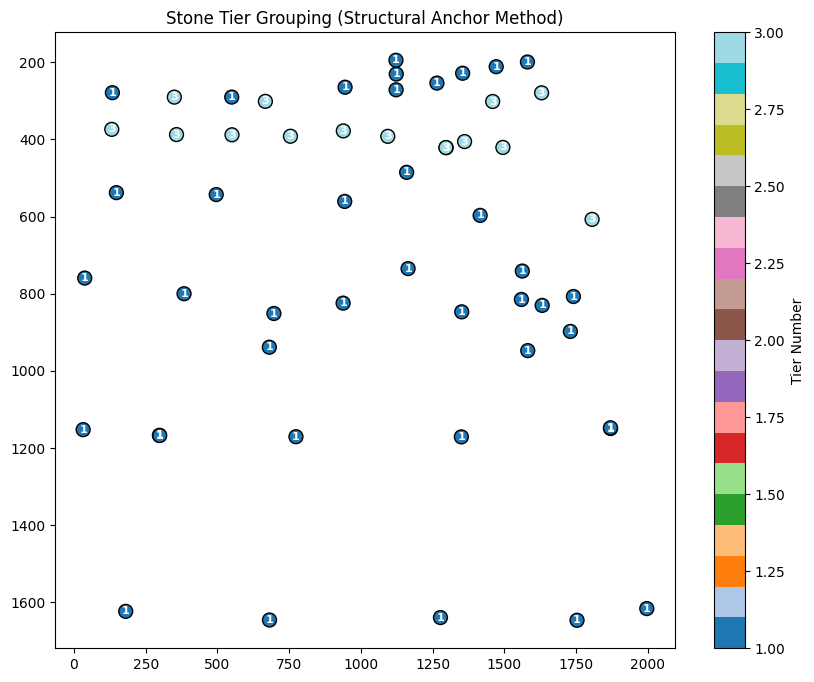

--- 各段の石の数 ---
Tier
1    40
3    15
Name: count, dtype: int64


In [3]:
# --- 4. 実行ブロック（修正：構造石基準） ---

if __name__ == "__main__":
    current_masks, df = main()

    if current_masks is not None and df is not None:
        print("構造石基準のグルーピングを開始します...")
        
        # 関数呼び出しを差し替え
        df = add_structural_tiering(current_masks, df)
        
        # 可視化
        plt.figure(figsize=(10, 8))
        plt.gca().invert_yaxis()
        scatter = plt.scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=100, edgecolors='k')
        plt.colorbar(scatter, label='Tier Number')
        
        for idx, row in df.iterrows():
            plt.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Tier'])), color='white', ha='center', va='center', fontsize=8, fontweight='bold')
            
        plt.title("Stone Tier Grouping (Structural Anchor Method)")
        plt.show()
        
        print("--- 各段の石の数 ---")
        print(df['Tier'].value_counts().sort_index())

水平方向の隣接関係を解析中...


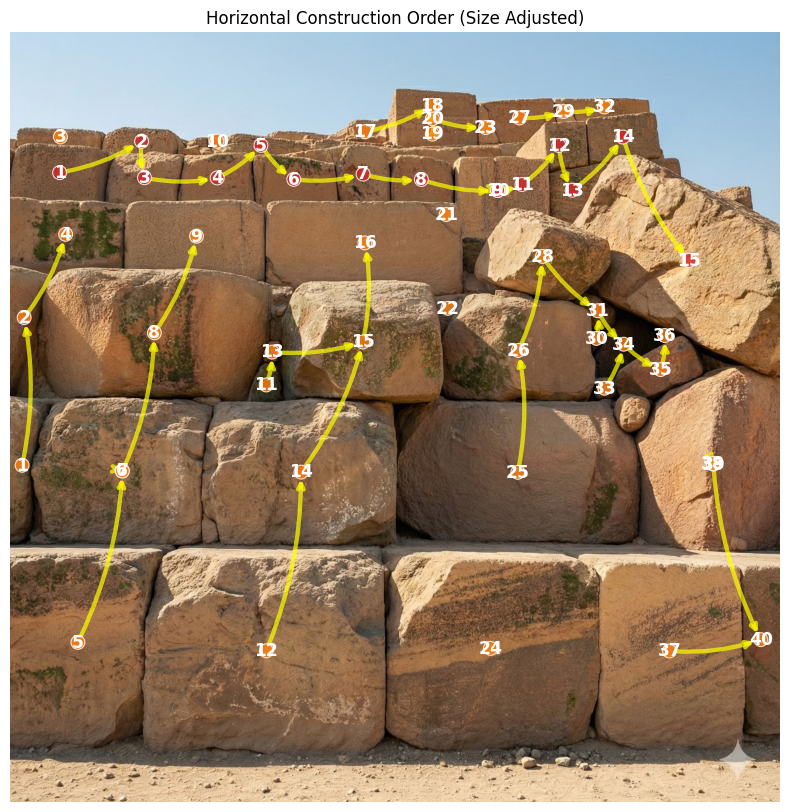

In [ ]:
# --- 5. 水平方向のグラフ化とサイズ調整された可視化 ---

def build_horizontal_adjacency_graph(masks, df, dilate_px=10):
    print(f"水平方向の隣接関係を解析中...")
    G = nx.DiGraph()
    mask_dict = {row['Stone_ID']: masks[i]['segmentation'] for i, row in df.iterrows()}
    
    for _, row in df.iterrows():
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']), tier=row['Tier'])

    for tier_id in sorted(df['Tier'].unique()):
        tier_stones = df[df['Tier'] == tier_id].sort_values('Centroid_X')['Stone_ID'].tolist()
        for i, id_a in enumerate(tier_stones):
            mask_a = mask_dict[id_a]
            kernel = np.ones((dilate_px, dilate_px), np.uint8)
            dilated_a = cv2.dilate(mask_a.astype(np.uint8), kernel, iterations=1)
            
            for j in range(i + 1, min(i + 4, len(tier_stones))):
                id_b = tier_stones[j]
                if np.logical_and(dilated_a, mask_dict[id_b]).any():
                    # ★ここで将来的に「斬り合い判定」の戻り値を使い、向きを決める
                    G.add_edge(id_a, id_b)
                    break 
    return G

def visualize_horizontal_analysis(image, G, df, node_scale=0.3, edge_scale=0.4):
    h, w = image.shape[:2]
    plt.figure(figsize=(15, 10))
    plt.imshow(image)
    ax = plt.gca()
    ax.set_xlim(0, w); ax.set_ylim(h, 0)
    base_scale = np.sqrt(df['Area'].mean()) / 50.0

    for u, v in G.edges():
        ax.annotate("", xy=G.nodes[v]['pos'], xytext=G.nodes[u]['pos'],
                    arrowprops=dict(arrowstyle="->", color="yellow", lw=1.5*base_scale*edge_scale, 
                                   alpha=0.7, shrinkA=5, shrinkB=5, connectionstyle="arc3,rad=0.1"))

    # 横方向のランクを再計算
    df['Construction_Rank'] = df.groupby('Tier')['Centroid_X'].rank(method='dense').astype(int)

    for _, row in df.iterrows():
        color = plt.cm.tab10(int(row['Tier']) % 10)
        radius = 12 * base_scale * node_scale
        ax.add_patch(plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, color=color, ec='white', lw=0.8, alpha=0.8, zorder=5))
        ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Construction_Rank'])), color='white', ha='center', va='center', 
                fontsize=8*base_scale*node_scale, fontweight='bold', zorder=6)

    plt.title("Horizontal Construction Order (Size Adjusted)")
    plt.axis('off'); plt.show()

# 実行 なんか上手くいかん
if 'df' in locals() and 'current_masks' in locals():
    G_horizontal = build_horizontal_adjacency_graph(current_masks, df, dilate_px=15)
    image_rgb = cv2.cvtColor(cv2.imread("images/pyramid2_test.jpeg"), cv2.COLOR_BGR2RGB) # パス確認
    visualize_horizontal_analysis(image_rgb, G_horizontal, df, node_scale=0.3, edge_scale=0.4)